# Data Cleaning and Smoothing for Landsat and Sentinel-2 SLA Data
Description: This notebook performs the cleaning, weighting, and smoothing of raw SLA data extracted via Google Earth Engine. It applies quality weights based on 'percentage_classified' parameter and snowline velocity, compares 5-image vs. 20-day smoothing methods, and as well 10-day vs 20-day vs. 30-day smoothing methods. Finally it exports the final dataset with the weights and weighted, smoothed sla values.

*The Code in this notebook was written with the help of AI (Gemini, Version 3.1 Pro)*

In [1]:
# Setup and Imports
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import glob 
import os 

# Define Directories
BASE_DIR = '../data/LS_Data/raw_sla'
OUTPUT_DIR = '../data/LS_Data/weighted_smoothed'

## 1. Data Loading and Initial Cleaning
Load all glacier datasets, filter for valid years (2000-2025) and summer months (May-October), and remove null SLA median values.

In [2]:
all_files = glob.glob(f"{BASE_DIR}/SLA_*.csv")
clean_glaciers = {}

for file_path in all_files:
    file_name = os.path.basename(file_path)
    glacier_name = file_name.split('_')[-1].replace('.csv', '')
    
    df = pd.read_csv(file_path)
    df = df[df['SLA_MP-median'] != 0].copy()
    
    df['time_date-string'] = pd.to_datetime(df['time_date-string'])
    df = df.sort_values('time_date-string')
    df = df[(df['time_date-string'].dt.year >= 2000) & (df['time_date-string'].dt.year <= 2025)].copy()
    df = df[df['time_date-string'].dt.month.between(5, 10)].copy()
    
    clean_glaciers[glacier_name] = df

print(f"Glaciers loaded: {len(clean_glaciers)}")

Glaciers loaded: 19


## 2. Applying Quality Weights
To account for classification errors and physically unrealistic snowline jumps, two weights are assigned. The classification weight penalizes images with <85% clear pixels. The velocity weight penalizes jumps that exceed 40m/day. These are combined into LS_weight_final.
In the next cell the weight for the 'percentage_classified' parameter gets defined in a function, and then apply to every glacier.

In [3]:
# Define the weighting function for 'percentage_classified'
def calculate_class_weight(percent_class):
    """
    Assigns weights based on a 70% minimum and 85% optimal threshold:
    - 70% and lower gets minimum weight  0.1
    - 85% and above gets maximum weight 1.0 
    - weight linearly increases between 70% and 85% 
    """
    perfect_threshold = 85.0
    penalty_threshold = 70.0
    max_weight = 1.0
    min_weight = 0.1
    
    if pd.isna(percent_class):
        return np.nan
        
    # 1. Everything <= 70% gets the minimum weight
    if percent_class <= penalty_threshold:
        return min_weight
        
    # 2. 'Perfect' classification, everything >= 85% gets full weight
    elif percent_class >= perfect_threshold:
        return max_weight
        
    # 3. Everything between 70 and 85 gets a sliding value
    else:
        fraction = (percent_class - penalty_threshold) / (perfect_threshold - penalty_threshold)
        return min_weight + (fraction * (max_weight - min_weight))

#Apply the function to every glacier in the dictionary
for name, df in clean_glaciers.items():
    
    # Apply the function and create the weight
    df['weight_class'] = df['percent_classified'].apply(calculate_class_weight)
    
    # Save it back into the dictionary 
    clean_glaciers[name] = df

## 3. Defining Velocity Weight Function and applying it
The function for the rate of change in SLA gets defined here, taking 40m/day still as acceptable with the maximum weight of 1.0, and everything above 100m/day gets assigned with the minimum weight of 0.1. Furthermore some safety rules had to be applied. Every first image of the dataset gets the maximum weight, and every image with a days gap of more than 100 days is also assigned with the maximum weight. Images with more than 100 days gap are considered the first image in spring again after a winter gap. As for these images it is not possible to calculate a reference jump per day value, they are simply fully trusted. Then the function gets applied to every glacier. To do so, first the rate of change per day is calculated for each glacier. The absolute altitude jump between the neighbour images gets defined and then divided by the days passed between these two images. 

In [4]:
# Define the function to give a weight for the rate of change in sla
def calculate_velocity_weight(rate, days_gap):
    """
    Assigns a weight based on how fast the snowline moved (m/day).
    - 40m/day and lower gets maximum weight 1.0
    - 100m/day and higher gets minimum weight 0.1
    - weight linearly decrease between 40 and 100m/day  
    """
    perfect_threshold = 40.0
    penalty_threshold = 100.0
    max_weight = 1.0
    min_weight =0.1
    
    # Safety rules
    if pd.isna(rate) or pd.isna(days_gap):
        return max_weight # First image of the dataset gets full weight
    
    if days_gap > 100.0:
        return max_weight # First image of the spring gets full weight 
        
    if days_gap == 0.0:
        return max_weight # if there should be images on the same day, apply full weight
        
    # Apply the thresholds

    # jumps with less than 40m/day get the maximum weight
    if rate <= perfect_threshold:
        return max_weight
        
    # jumps with more than 100m/day get the minimum weight
    elif rate >= penalty_threshold:
        return min_weight
    else:
        fraction = (rate - perfect_threshold) / (penalty_threshold - perfect_threshold)
        return max_weight - (fraction * (max_weight - min_weight))

# Apply the function to every glacier in the dictionary
for name, df in clean_glaciers.items():
    
    # 1. Ensure sorted by date 
    df = df.sort_values('time_date-string')

    # 2. Calculate the Absolute Altitude Jump (meters) and days since last image
    df['sla_jump_meters'] = df['SLA_MP-median'].diff().abs()
    df['days_since_last_image'] = df['time_date-string'].diff().dt.days 

    # 3. Calculate Rate of Change (meters per day)
    df['rate_meters_per_day'] = df['sla_jump_meters'] / df['days_since_last_image']

    # 4. Apply the function and create the weights
    df['weight_velocity'] = df.apply(
        lambda row: calculate_velocity_weight(row['rate_meters_per_day'], row['days_since_last_image']), 
        axis=1
    )
    
    clean_glaciers[name] = df

## 4. Calculate the final combined weight
The 'weight_class' and the 'weight_velocity' get combined here.
The weight_class is the more important weight as it directly is built upon a variable of the data, therefore it gets assigned with 70% of the final weight.
The weight_velocity is less trusted and therefor gets assigned with 30% of the final weight. 

In [5]:
#Calculate a final combined Landsat/Sentinel weight
for name, df in clean_glaciers.items():
    df['LS_weight_final'] = ((df['weight_class'] * 0.70) + (df['weight_velocity'] * 0.30)).round(4)
    
    clean_glaciers[name] = df

## 5. Dual Smoothing Application (row-based vs. time-aware)
A row-based (5-image) and time-aware (20-day) moving average gets applied to the weighted data to determine the most physically accurate representation of the snowline. 

In [6]:
# Define the function for the smoothing
# The function includes both methods
# First the image-based smoothing
# Then the time-aware smoothing
def smooth_landsat_sla_dual(df, window_days=20):
    """
    Calculates both the row-based (5-image) and time-aware (20-day) smoothing.
    The time-aware window size is dynamically set by 'window_days' (default is 20).
    """

    date_col='time_date-string'
    weight_col='LS_weight_final'
    
    # 1. Make copy of df to be save
    df_sorted = df.copy()
    
    # 5-image based smoothing 
    # Unweighted 5-image smoothing
    df_sorted['SLA_unweighted_5img'] = df_sorted['SLA_MP-median'].rolling(
        window=5, center=True, min_periods=1
    ).mean().round(4)

    # Weighted 5-image smoothing
    df_sorted['temp_vw'] = df_sorted['SLA_MP-median'] * df_sorted[weight_col]
    rolling_num_5i = df_sorted['temp_vw'].rolling(window=5, center=True, min_periods=1).sum()
    rolling_den_5i = df_sorted[weight_col].rolling(window=5, center=True, min_periods=1).sum()
    
    df_sorted['SLA_weighted_5img'] = (rolling_num_5i / rolling_den_5i).round(4)
    df_sorted = df_sorted.drop(columns=['temp_vw'])

    # Time-aware smoothing (20-day)
    # 1. Build daily calendar
    full_dates = pd.date_range(df_sorted[date_col].min(), df_sorted[date_col].max(), freq='D')
    calendar = pd.DataFrame(index=full_dates)
    calendar.index.name = date_col
    
    # 2. Put the observations onto the calendar
    obs = df_sorted.set_index(date_col)
    merged = calendar.join(obs, how='left')

    # Unweighted Time-Aware smoothing
    merged[f'SLA_unweighted_{window_days}day'] = merged['SLA_MP-median'].rolling(
        window=window_days, center=True, min_periods=1
    ).mean().round(4)

    # Weighted Time-Aware smoothing
    merged['temp_vw'] = merged['SLA_MP-median'] * merged[weight_col]
    rolling_num_td = merged['temp_vw'].rolling(window=window_days, center=True, min_periods=1).sum()
    rolling_den_td = merged[weight_col].rolling(window=window_days, center=True, min_periods=1).sum()
    
    merged[f'SLA_weighted_{window_days}day'] = (rolling_num_td / rolling_den_td).round(4)

    # Drop empty calendar days so only days with actual images are kept
    final_df = merged.dropna(subset=['SLA_MP-median']).reset_index()
    final_df = final_df.drop(columns=['temp_vw'])
    
    # Convert dates back to strings to match the original format
    final_df[date_col] = final_df[date_col].dt.strftime('%Y-%m-%d')
    
    return final_df

# apply the smoothing to every glacier
for name, df in clean_glaciers.items():
    
    df_smoothed = smooth_landsat_sla_dual(df, window_days=20)
    
    clean_glaciers[name] = df_smoothed

## 6. Visualization: Method Comparison
The two smoothing methods get visualised in two different plots. 
Both showing their weighted and unweighted smoothing result.

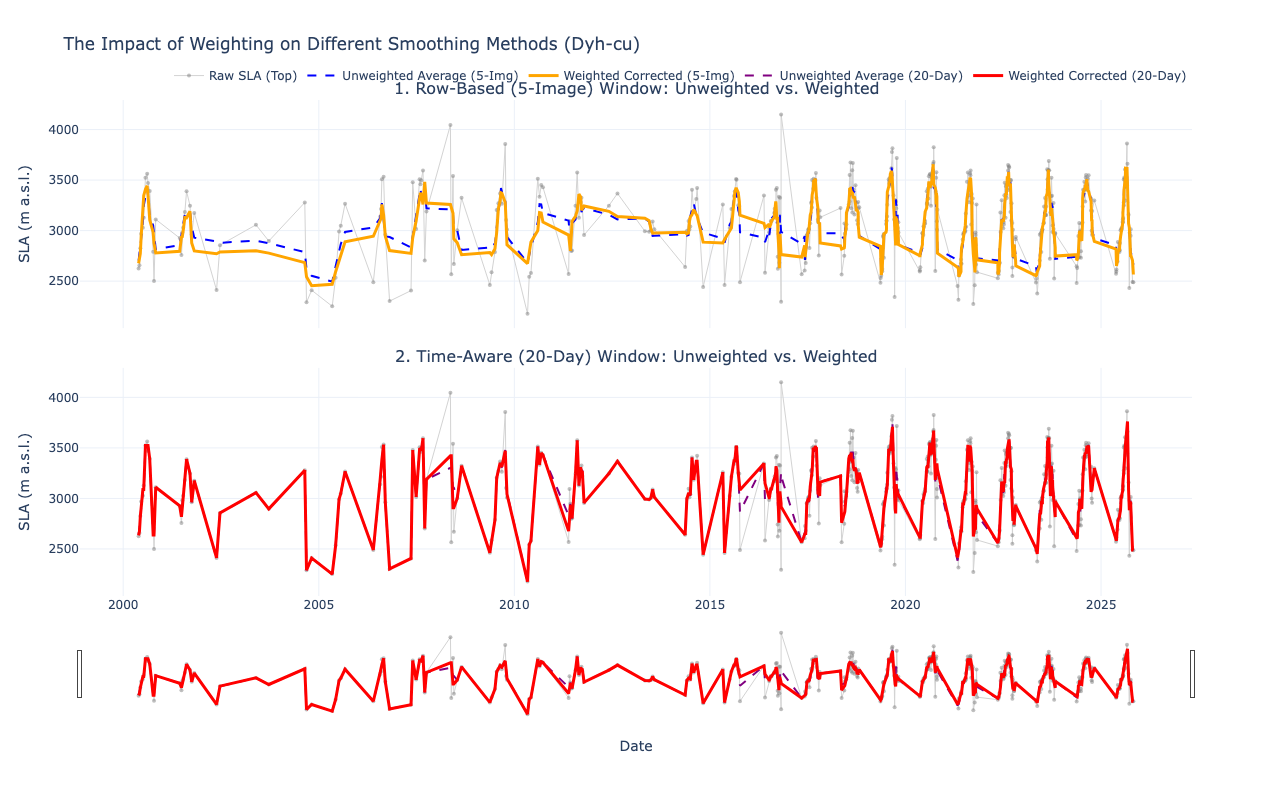

In [7]:
# Visualization: unweighted vs. weighted smoothing
GLACIER_TO_PLOT = 'Dyh-cu' 

if GLACIER_TO_PLOT in clean_glaciers:
    df_plot = clean_glaciers[GLACIER_TO_PLOT]

    # Create figure
    fig_compare = make_subplots(
        rows=2, cols=1, 
        shared_xaxes=True, 
        vertical_spacing=0.08,
        subplot_titles=(
            "1. Row-Based (5-Image) Window: Unweighted vs. Weighted", 
            "2. Time-Aware (20-Day) Window: Unweighted vs. Weighted"
        )
    )

    # 5-image based
    # 1. Raw Data
    fig_compare.add_trace(go.Scatter(
        x=df_plot['time_date-string'], y=df_plot['SLA_MP-median'],
        mode='lines+markers', name='Raw SLA (Top)', 
        marker=dict(color='gray', opacity=0.5, size=4),
        line=dict(color='lightgray', width=1)
    ), row=1, col=1)

    # 2. Unweighted 5-Image
    fig_compare.add_trace(go.Scatter(
        x=df_plot['time_date-string'], y=df_plot['SLA_unweighted_5img'],
        mode='lines', name='Unweighted Average (5-Img)', 
        line=dict(color='blue', width=2, dash='dash')
    ), row=1, col=1)

    # 3. Weighted 5-Image
    fig_compare.add_trace(go.Scatter(
        x=df_plot['time_date-string'], y=df_plot['SLA_weighted_5img'],
        mode='lines', name='Weighted Corrected (5-Img)', 
        line=dict(color='orange', width=3)
    ), row=1, col=1)


    # 20-day time-aware
    # 1. Raw Data 
    fig_compare.add_trace(go.Scatter(
        x=df_plot['time_date-string'], y=df_plot['SLA_MP-median'],
        mode='lines+markers', name='Raw SLA', showlegend=False,
        marker=dict(color='gray', opacity=0.5, size=4),
        line=dict(color='lightgray', width=1)
    ), row=2, col=1)

    # 2. Unweighted 20-Day
    fig_compare.add_trace(go.Scatter(
        x=df_plot['time_date-string'], y=df_plot['SLA_unweighted_20day'],
        mode='lines', name='Unweighted Average (20-Day)', 
        line=dict(color='purple', width=2, dash='dash')
    ), row=2, col=1)

    # 3. Weighted 20-Day
    fig_compare.add_trace(go.Scatter(
        x=df_plot['time_date-string'], y=df_plot['SLA_weighted_20day'],
        mode='lines', name='Weighted Corrected (20-Day)', 
        line=dict(color='red', width=3)
    ), row=2, col=1)


    # Layout and formatting
    fig_compare.update_layout(
        title=f"The Impact of Weighting on Different Smoothing Methods ({GLACIER_TO_PLOT})",
        height=800, 
        template="plotly_white", 
        hovermode='x unified',
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )

    # Set the y-axis titles for both plots
    fig_compare.update_yaxes(title_text="SLA (m a.s.l.)", row=1, col=1)
    fig_compare.update_yaxes(title_text="SLA (m a.s.l.)", row=2, col=1)
    fig_compare.update_xaxes(title_text="Date", row=2, col=1)

    # Add a range slider only to the bottom
    fig_compare.update_xaxes(rangeslider_visible=True, row=2, col=1)

    fig_compare.show()
else:
    print(f"Error: Could not find '{GLACIER_TO_PLOT}' in your data dictionary.")

## 7. Different window sizes for time-aware smoothing
This analyzes the effect of the smoothing when using different window sizes. A 10-day, 20-day and 30-day window size get compared. Therefore a smoothing function gets defined and applied to every glacier.

In [8]:
# Define time-aware smoothing method with different window sizes
def smooth_landsat_multi_window(df, windows=[10, 20, 30]):
    """
    Calculates time-aware smoothing for multiple window sizes side-by-side.
    """
    date_col='time_date-string'
    weight_col='LS_weight_final'
    
    df_sorted = df.copy()
    df_sorted[date_col] = pd.to_datetime(df_sorted[date_col])
    
    # 1. Build daily calendar
    full_dates = pd.date_range(df_sorted[date_col].min(), df_sorted[date_col].max(), freq='D')
    calendar = pd.DataFrame(index=full_dates)
    calendar.index.name = date_col
    
    # 2. Put observations onto the calendar
    obs = df_sorted.set_index(date_col)
    merged = calendar.join(obs, how='left')

    # 3. Loop through every defined window size
    for w in windows:
        # Unweighted Time-Aware
        merged[f'SLA_unweighted_{w}day'] = merged['SLA_MP-median'].rolling(
            window=w, center=True, min_periods=1
        ).mean().round(4)

        # Weighted Time-Aware
        merged['temp_vw'] = merged['SLA_MP-median'] * merged[weight_col]
        rolling_num = merged['temp_vw'].rolling(window=w, center=True, min_periods=1).sum()
        rolling_den = merged[weight_col].rolling(window=w, center=True, min_periods=1).sum()
        
        merged[f'SLA_weighted_{w}day'] = (rolling_num / rolling_den).round(4)
        merged = merged.drop(columns=['temp_vw'])

    # 4. Drop empty calendar days
    final_df = merged.dropna(subset=['SLA_MP-median']).reset_index()
    
    # Convert dates back to strings
    final_df[date_col] = final_df[date_col].dt.strftime('%Y-%m-%d')
    
    return final_df

# Apply the function to all glaciers
for name, df in clean_glaciers.items():
    # Pass the list of windows [10, 20, 30] into the function
    df_smoothed = smooth_landsat_multi_window(df, windows=[10, 20, 30])
    
    clean_glaciers[name] = df_smoothed

## 8. Visualization of the different time-aware smoothing windows
The smoothing with the three different window sizes are visualised here, to be able to compare the difference.

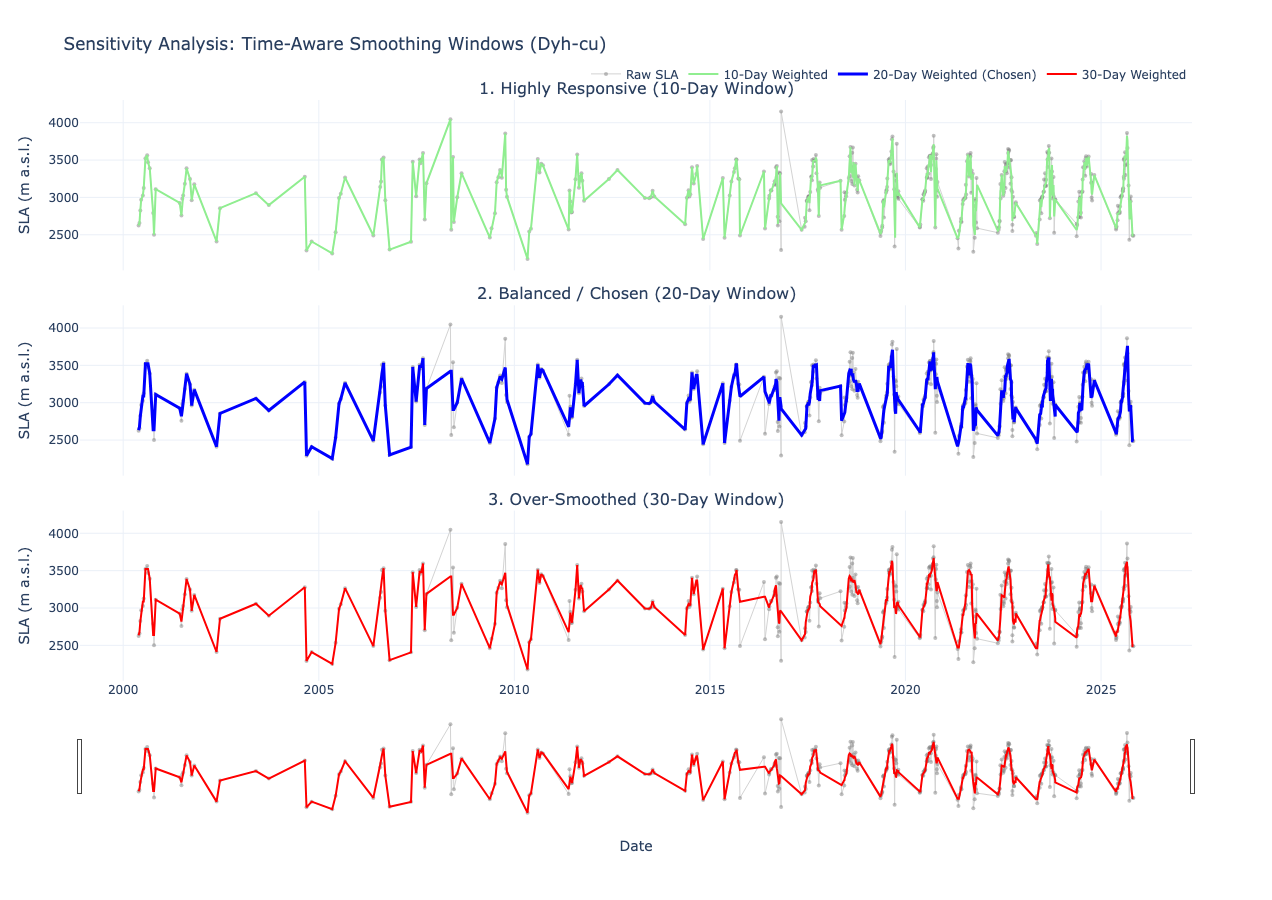

In [9]:
# Visualization: 10 vs. 20 vs. 30-day windows
GLACIER_TO_PLOT = 'Dyh-cu' 

if GLACIER_TO_PLOT in clean_glaciers:
    df_plot = clean_glaciers[GLACIER_TO_PLOT]

    # Create stacked subplot 
    fig_compare = make_subplots(
        rows=3, cols=1, 
        shared_xaxes=True,
        vertical_spacing=0.06,
        subplot_titles=(
            "1. Highly Responsive (10-Day Window)", 
            "2. Balanced / Chosen (20-Day Window)",
            "3. Over-Smoothed (30-Day Window)"
        )
    )

    # 10-day window
    # 1. Raw Data
    fig_compare.add_trace(go.Scatter(
        x=df_plot['time_date-string'], y=df_plot['SLA_MP-median'],
        mode='lines+markers', name='Raw SLA', 
        marker=dict(color='gray', opacity=0.5, size=4),
        line=dict(color='lightgray', width=1)
    ), row=1, col=1)

    # 2. 10-Day Smoothed
    fig_compare.add_trace(go.Scatter(
        x=df_plot['time_date-string'], y=df_plot['SLA_weighted_10day'],
        mode='lines', name='10-Day Weighted', 
        line=dict(color='lightgreen', width=2)
    ), row=1, col=1)

    # 20-day window
    # 1. Raw Data 
    fig_compare.add_trace(go.Scatter(
        x=df_plot['time_date-string'], y=df_plot['SLA_MP-median'],
        mode='lines+markers', name='Raw SLA', showlegend=False,
        marker=dict(color='gray', opacity=0.5, size=4),
        line=dict(color='lightgray', width=1)
    ), row=2, col=1)

    # 2. 20-Day Smoothed
    fig_compare.add_trace(go.Scatter(
        x=df_plot['time_date-string'], y=df_plot['SLA_weighted_20day'],
        mode='lines', name='20-Day Weighted (Chosen)', 
        line=dict(color='blue', width=3)
    ), row=2, col=1)

    # 30-day window
    # 1. Raw Data 
    fig_compare.add_trace(go.Scatter(
        x=df_plot['time_date-string'], y=df_plot['SLA_MP-median'],
        mode='lines+markers', name='Raw SLA', showlegend=False,
        marker=dict(color='gray', opacity=0.5, size=4),
        line=dict(color='lightgray', width=1)
    ), row=3, col=1)

    # 2. 30-Day Smoothed
    fig_compare.add_trace(go.Scatter(
        x=df_plot['time_date-string'], y=df_plot['SLA_weighted_30day'],
        mode='lines', name='30-Day Weighted', 
        line=dict(color='red', width=2)
    ), row=3, col=1)

    
    # Layout and formatting
    fig_compare.update_layout(
        title=f"Sensitivity Analysis: Time-Aware Smoothing Windows ({GLACIER_TO_PLOT})",
        height=900, 
        template="plotly_white", 
        hovermode='x unified',
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )

    fig_compare.update_yaxes(title_text="SLA (m a.s.l.)", row=1, col=1)
    fig_compare.update_yaxes(title_text="SLA (m a.s.l.)", row=2, col=1)
    fig_compare.update_yaxes(title_text="SLA (m a.s.l.)", row=3, col=1)
    
    fig_compare.update_xaxes(title_text="Date", row=3, col=1)

    # Add the range slider only to the bottom
    fig_compare.update_xaxes(rangeslider_visible=True, row=3, col=1)

    fig_compare.show()
else:
    print(f"Error: Could not find '{GLACIER_TO_PLOT}' in your data dictionary.")

## 9. Visualization in overlaid version
Here just one plot is created to see the effect of the different window sizes directly overlaid. 

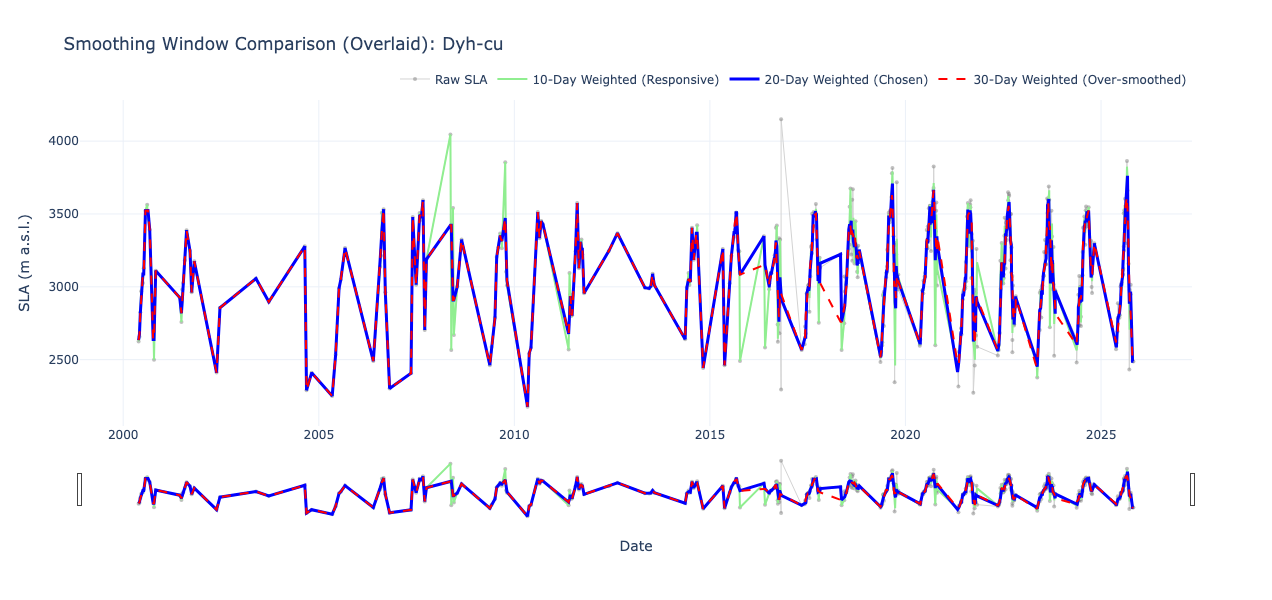

In [10]:
# Visualization: all smoothing windows overlaid in one plot
GLACIER_TO_PLOT = 'Dyh-cu' 

if GLACIER_TO_PLOT in clean_glaciers:
    df_plot = clean_glaciers[GLACIER_TO_PLOT]

    fig_overlay = go.Figure()

    # 1. Raw Data 
    fig_overlay.add_trace(go.Scatter(
        x=df_plot['time_date-string'], y=df_plot['SLA_MP-median'],
        mode='lines+markers', name='Raw SLA', 
        marker=dict(color='gray', opacity=0.5, size=4),
        line=dict(color='lightgray', width=1)
    ))

    # 2. 10-Day Window 
    fig_overlay.add_trace(go.Scatter(
        x=df_plot['time_date-string'], y=df_plot['SLA_weighted_10day'],
        mode='lines', name='10-Day Weighted (Responsive)', 
        line=dict(color='lightgreen', width=2)
    ))

    # 3. 20-Day Window 
    fig_overlay.add_trace(go.Scatter(
        x=df_plot['time_date-string'], y=df_plot['SLA_weighted_20day'],
        mode='lines', name='20-Day Weighted (Chosen)', 
        line=dict(color='blue', width=3)
    ))

    # 4. 30-Day Window 
    fig_overlay.add_trace(go.Scatter(
        x=df_plot['time_date-string'], y=df_plot['SLA_weighted_30day'],
        mode='lines', name='30-Day Weighted (Over-smoothed)', 
        line=dict(color='red', width=2, dash='dash')
    ))

    # Layout and formatting
    fig_overlay.update_layout(
        title=f"Smoothing Window Comparison (Overlaid): {GLACIER_TO_PLOT}",
        height=600, 
        template="plotly_white", 
        hovermode='x unified',
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )

    # Set axes titles
    fig_overlay.update_yaxes(title_text="SLA (m a.s.l.)")
    fig_overlay.update_xaxes(title_text="Date")

    # Add the range slider 
    fig_overlay.update_xaxes(rangeslider_visible=True)

    fig_overlay.show()
else:
    print(f"Error: Could not find '{GLACIER_TO_PLOT}' in your data dictionary.")

## 10. Final Export
The newly created data gets exported for each glacier. The files get saved under the name: "LS_glacierName_complete".
In this file all the data produced from the Landsat/Sentinel Dataset is included. Regarding the newly weighted and smoothed SLA data, only the weighted and unweighted smoothing of the 20-day time-aware smoothing gets exported. Based on the sensitivity analysis this is the best approach and only this data gets kept. 

In [12]:
os.makedirs(OUTPUT_DIR, exist_ok=True) 

# define columns to keep
columns_to_keep = [
    'time_date-string',
    'SLA_MP-median',
    'glacier_area_km2',
    'glacier_glims_id',
    'glacier_name',
    'weight_velocity',
    'weight_class',
    'LS_weight_final',
    'SLA_unweighted_20day',
    'SLA_weighted_20day'
]

for name, df in clean_glaciers.items():

    df_complete = df[columns_to_keep].copy()
     
    output_path = f"{OUTPUT_DIR}/LS_{name}_complete.csv"
    
    df_complete.to_csv(output_path, index=False)

# Check if everything is included
print("\nSnapshot of the final clean format (Example: Caneri):")
if 'Caneri' in clean_glaciers:
    display(clean_glaciers['Caneri'][columns_to_keep].head())


Snapshot of the final clean format (Example: Caneri):


,time_date-string,SLA_MP-median,glacier_area_km2,glacier_glims_id,glacier_name,weight_velocity,weight_class,LS_weight_final,SLA_unweighted_20day,SLA_weighted_20day
0,2000-05-15,3872.0,13.943723,G042999E43050N,Caneri,1.000000,0.4888,0.6422,3163.00,3117.6347
1,2000-05-24,2454.0,13.943723,G042999E43050N,Caneri,0.100000,1.0000,0.7300,3104.00,3033.2963
2,2000-05-31,2596.0,13.943723,G042999E43050N,Caneri,1.000000,0.1000,0.3700,2873.25,2645.9239
3,2000-06-01,3494.0,13.943723,G042999E43050N,Caneri,0.100000,0.1000,0.1000,2873.25,2645.9239
4,2000-06-09,2949.0,13.943723,G042999E43050N,Caneri,0.578125,0.1000,0.2434,2948.60,2848.9856
